# QUBO — Radni primeri

Ovaj notebook prolazi kroz nekoliko konkretnih optimizacionih problema, pokazuje kako se svaki formuliše kao QUBO, i rešava ga brute-force pretragom i simuliranim žarenjem.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ── Ocean SDK (D-Wave) ───────────────────────────────────
import dimod                          # BinaryQuadraticModel, ExactSolver, SampleSet
import neal                           # SimulatedAnnealingSampler
import dwave_networkx as dnx          # Graf algoritmi (max-cut, MIS, vertex cover…)
# ────────────────────────────────────────────────────────

# Globalni sampleri — koristimo ih kroz sve primere
exact_solver = dimod.ExactSolver()                  # brute-force, tačno (n ≤ 20)
sa_sampler   = neal.SimulatedAnnealingSampler()     # simulirano žarenje

print(f"dimod         : {dimod.__version__}")
print(f"neal          : {neal.__version__}")
print(f"dwave_networkx: {dnx.__version__}")
print("\nOcean SDK učitan ✓")

dimod         : 0.12.21
neal          : 0.6.0
dwave_networkx: 0.8.18

Ocean SDK učitan ✓


## Uvodni primer 0: "Hello QUBO" — 2 promenljive

Pre složenih problema, pogledajmo **najjednostavniji mogući QUBO** sa 2 promenljive.

### Problem: Minimizuj $f(x_1, x_2) = x_1 + x_2 - 2x_1 x_2$

QUBO matrica (gornje-trougaona forma u kojoj je $Q_{ij}$ koeficijent uz $x_i x_j$):
$$Q = \begin{pmatrix} 1 & -2 \\ 0 & 1 \end{pmatrix}$$

| $x_1$ | $x_2$ | $f$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 1 | 0 | 1 |
| 0 | 1 | 1 |
| 1 | 1 | 0 |

Minimum je 0, dostignut u $(0,0)$ i $(1,1)$ — QUBO može imati **više globalnih optima**.

### Ključni koncepti Ocean SDK

**`BinaryQuadraticModel` (BQM)** — centralni objekat Ocean SDK-a. Prima:
- `linear` — rečnik `{promenljiva: koeficijent}` (dijagonalni elementi $Q_{ii}$)
- `quadratic` — rečnik `{(promenljiva_i, promenljiva_j): koeficijent}` (van-dijagonalni $Q_{ij}$)
- `offset` — konstantni term (ne utiče na optimum)
- `vartype='BINARY'` — promenljive su $x \in \{0, 1\}$ (QUBO forma)

**`ExactSolver`** — isprobava sva $2^n$ rešenja i vraća ih sortirana po energiji kao **`SampleSet`**. Egzaktno, ali eksponencijalno — koristi samo za $n \leq 20$.

**`SampleSet.first`** — najniže-energetsko rešenje. Svaki unos sadrži `.sample` (rečnik vrednosti) i `.energy` (vrednost $f$).

In [22]:
bqm_hello = dimod.BinaryQuadraticModel(
    {'x1': 1, 'x2': 1},
    {('x1', 'x2'): -2},
    0.0,
    vartype='BINARY'
)

print("BQM: f(x1, x2) = x1 + x2 - 2·x1·x2\n")
print(f"{'x1':>4} {'x2':>4} | {'f(x)':>6}")
print("-" * 20)

ss_hello = exact_solver.sample(bqm_hello)
for sample, energy in ss_hello.data(['sample', 'energy']):
    marker = " ← minimum" if energy == ss_hello.first.energy else ""
    print(f"{sample['x1']:>4} {sample['x2']:>4} | {energy:>6.1f}{marker}")

print(f"\nMinimalna energija: {ss_hello.first.energy:.1f}")
print(f"SampleSet tip     : {type(ss_hello)}")
print(f"Broj rešenja      : {len(ss_hello)}")

BQM: f(x1, x2) = x1 + x2 - 2·x1·x2

  x1   x2 |   f(x)
--------------------
   0    0 |    0.0 ← minimum
   1    1 |    0.0 ← minimum
   1    0 |    1.0
   0    1 |    1.0

Minimalna energija: 0.0
SampleSet tip     : <class 'dimod.sampleset.SampleSet'>
Broj rešenja      : 4


## Uvodni primer 1: Odabir tačno jednog elementa (One-Hot)

**Problem:** Od $n$ opcija, odaberi **tačno jednu**.

### QUBO formulacija korak po korak

Uslov je $\sum_{i=1}^{n} x_i = 1$. Enkodujemo ga kaznenim termom koji je nula jedino kada je uslov ispunjen:

$$f(\mathbf{x}) = P\left(1 - \sum_{i=1}^{n} x_i\right)^2$$

Razvijamo kvadrat:
$$f = P\left(1 - 2\sum_i x_i + \left(\sum_i x_i\right)^2\right)$$

Koristeći $x_i^2 = x_i$ (ključna osobina binarnih promenljivih!) i $\left(\sum_i x_i\right)^2 = \sum_i x_i^2 + 2\sum_{i<j} x_i x_j$:

$$f = P\left(1 - 2\sum_i x_i + \sum_i x_i + 2\sum_{i<j}x_ix_j\right) = P\left(1 - \sum_i x_i + 2\sum_{i<j}x_ix_j\right)$$

Iz toga čitamo QUBO koeficijente:
- **Dijagonala:** $Q_{ii} = -P$ za sve $i$  *(koeficijent uz $x_i$)*
- **Van-dijagonale:** $Q_{ij} = 2P$ za $i < j$  *(koeficijent uz $x_ix_j$)*
- **Offset:** $+P$ (ne utiče na optimum)

### Energija po broju izabranih opcija

| Izabrano $k = \sum x_i$ | $f$ |
|:---:|:---:|
| 0 | $P$ (niko nije izabran — kazna) |
| **1** | **0** (tačno jedna opcija — minimum!) |
| 2 | $P$ (dve opcije — kazna) |
| 3 | $4P$ (tri opcije — veća kazna) |

> **One-Hot ograničenje je najčešći gradivni blok u QUBO formulacijama** — pojavljuje se svuda gde treba birati tačno jednu opciju: bojenje grafova, TSP, raspored zadataka, portfelj optimizacija.

In [21]:
opcije = ['Beograd', 'Novi Sad', 'Niš', 'Kragujevac']
n_oh   = len(opcije)
P_oh   = 5

linear_oh    = {i: -P_oh for i in range(n_oh)}
quadratic_oh = {(i, j): 2*P_oh for i in range(n_oh) for j in range(i+1, n_oh)}
bqm_onehot   = dimod.BinaryQuadraticModel(linear_oh, quadratic_oh, P_oh, vartype='BINARY')

ss_oh = exact_solver.sample(bqm_onehot)

print("One-Hot QUBO: biramo tačno jednu od 4 destinacije\n")
print(f"{'Izabrano':>30} | {'Σxi':>4} | {'Energija':>10} | {'OK?':>4}")
print("-" * 57)
for sample, energy in ss_oh.data(['sample', 'energy']):
    odabrano = [opcije[i] for i in range(n_oh) if sample[i] == 1]
    suma = sum(sample[i] for i in range(n_oh))
    ok   = '✓' if suma == 1 else '✗'
    print(f"{str(odabrano):>30} | {suma:>4} | {energy:>10.1f} | {ok:>4}")

print(f"\nMinimalna energija = {ss_oh.first.energy:.1f} = -{P_oh} = -P")
print("Sva validna (one-hot) rešenja imaju energiju -P.")

One-Hot QUBO: biramo tačno jednu od 4 destinacije

                      Izabrano |  Σxi |   Energija |  OK?
---------------------------------------------------------
                   ['Beograd'] |    1 |        0.0 |    ✓
                  ['Novi Sad'] |    1 |        0.0 |    ✓
                       ['Niš'] |    1 |        0.0 |    ✓
                ['Kragujevac'] |    1 |        0.0 |    ✓
       ['Beograd', 'Novi Sad'] |    2 |        5.0 |    ✗
           ['Novi Sad', 'Niš'] |    2 |        5.0 |    ✗
            ['Beograd', 'Niš'] |    2 |        5.0 |    ✗
                            [] |    0 |        5.0 |    ✗
    ['Novi Sad', 'Kragujevac'] |    2 |        5.0 |    ✗
         ['Niš', 'Kragujevac'] |    2 |        5.0 |    ✗
     ['Beograd', 'Kragujevac'] |    2 |        5.0 |    ✗
['Beograd', 'Novi Sad', 'Niš'] |    3 |       20.0 |    ✗
['Beograd', 'Niš', 'Kragujevac'] |    3 |       20.0 |    ✗
['Novi Sad', 'Niš', 'Kragujevac'] |    3 |       20.0 |    ✗
['Beograd', 'Nov

## Uvodni primer 2: Particija skupa u dve grupe (2-Way Number Partitioning)

**Problem:** Dat je skup celih brojeva $\{a_1, \dots, a_n\}$. Podeli ih na **dve grupe jednakih suma**.

### Promenljive i formulacija

$x_i = 1$ ako $a_i$ ide u grupu 1, $x_i = 0$ ako ide u grupu 2.

Suma grupe 1: $\sum_i a_i x_i$, suma grupe 2: $\sum_i a_i (1-x_i) = S - \sum_i a_i x_i$

Cilj je da su sume jednake, tj. razlika = 0:
$$\text{razlika} = \sum_i a_i x_i - \left(S - \sum_i a_i x_i\right) = 2\sum_i a_i x_i - S$$

QUBO: minimizujemo kvadrat razlike:
$$f(\mathbf{x}) = \left(2\sum_i a_i x_i - S\right)^2$$

### Razvijanje u QUBO formu

Razvijamo kvadrat: $(2\sum_i a_i x_i - S)^2 = 4(\sum_i a_i x_i)^2 - 4S\sum_i a_i x_i + S^2$

Koristeći $x_i^2 = x_i$:

$$Q_{ii} = 4a_i^2 - 4Sa_i \qquad Q_{ij} = 8a_ia_j \text{ za } i < j \qquad \text{offset} = S^2$$

### Zašto je ovo moćno?

- **Nema eksplicitnih ograničenja** — ograničenje jednakih suma je direktno ugrađeno u cilj
- Optimalna energija je **tačno 0** jedino ako postoji savršena particija
- Ako savršena particija ne postoji, minimum daje **najbliže moguće** rešenje
- Ovo je NP-teški problem za opšti slučaj — QUBO formulacija mu daje prirodan oblik za kvantne solvere

In [20]:
a = np.array([3, 1, 1, 2, 2, 1], dtype=float)
n_part = len(a)
S_part = a.sum()
print(f"Skup: {list(a.astype(int))}")
print(f"Ukupna suma: S = {int(S_part)} → svaka grupa treba da ima {int(S_part/2)}\n")

# Gradnja BQM: f = (2·Σ aᵢxᵢ - S)²
linear_p    = {i: 4*a[i]**2 - 4*S_part*a[i] for i in range(n_part)}
quadratic_p = {(i, j): 8*a[i]*a[j] for i in range(n_part) for j in range(i+1, n_part)}
bqm_part    = dimod.BinaryQuadraticModel(linear_p, quadratic_p, S_part**2, vartype='BINARY')

ss_part = exact_solver.sample(bqm_part)

print(f"{'Grupa 1':>18} | {'S1':>3} | {'Grupa 2':>18} | {'S2':>3} | {'Energija':>10}")
print("-" * 65)
seen_part = set()
for sample, energy in ss_part.data(['sample', 'energy']):
    g1  = tuple(int(a[i]) for i in range(n_part) if sample[i] == 1)
    g2  = tuple(int(a[i]) for i in range(n_part) if sample[i] == 0)
    key = (min(g1, g2), max(g1, g2))
    if key in seen_part:
        continue
    seen_part.add(key)
    marker = " ← optimum" if energy == ss_part.first.energy else ""
    print(f"{str(list(g1)):>18} | {sum(g1):>3} | {str(list(g2)):>18} | {sum(g2):>3} | {energy:>10.1f}{marker}")
    if len(seen_part) >= 12:
        print("  ...")
        break

print(f"\nMinimalna energija: {ss_part.first.energy:.1f}  (0 = savršena particija)")

Skup: [np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1)]
Ukupna suma: S = 10 → svaka grupa treba da ima 5

           Grupa 1 |  S1 |            Grupa 2 |  S2 |   Energija
-----------------------------------------------------------------
         [3, 1, 1] |   5 |          [2, 2, 1] |   5 |        0.0 ← optimum
            [3, 2] |   5 |       [1, 1, 2, 1] |   5 |        0.0 ← optimum
         [1, 2, 2] |   5 |          [3, 1, 1] |   5 |        0.0 ← optimum
         [3, 1, 2] |   6 |          [1, 2, 1] |   4 |        4.0
            [2, 2] |   4 |       [3, 1, 1, 1] |   6 |        4.0
         [1, 1, 2] |   4 |          [3, 2, 1] |   6 |        4.0
            [3, 1] |   4 |       [1, 2, 2, 1] |   6 |        4.0
            [3, 1] |   4 |       [1, 1, 2, 2] |   6 |        4.0
      [3, 1, 1, 2] |   7 |             [2, 1] |   3 |       16.0
               [3] |   3 |    [1, 1, 2, 2, 1] |   7 |       16.0
         [1, 1, 1] |   3 |          [3, 2, 2] |   7 | 

## Primer 1: Problem ranca (Knapsack)

### Opis problema

Dat je ranac kapaciteta $W$ i $n$ predmeta. Svaki predmet $i$ ima **vrednost** $v_i$ i **težinu** $w_i$. Cilj je izabrati podskup predmeta koji **maksimizuje ukupnu vrednost** uz uslov da ukupna težina ne prelazi $W$.

### QUBO formulacija

Promenljive: $x_i = 1$ ako uzimamo predmet $i$, inače $x_i = 0$.

**Funkcija cilja** (maksimizacija ↔ minimizacija negativnog):
$$f_{\text{obj}} = -\sum_i v_i x_i$$

**Problem sa ograničenjem kapaciteta:** Ograničenje $\sum_i w_i x_i \leq W$ je *nejednakosno* — QUBO ne može direktno da ga enkoduje kao kvadratni term. Rešenje: uvedemo **slack promenljive**.

### Slack promenljive — zašto i koliko?

Nejednakost $\sum_i w_i x_i \leq W$ pretvaramo u jednakost dodavanjem slack-a $s$:
$$\sum_i w_i x_i + s = W, \qquad s \in \{0, 1, \dots, W\}$$

Vrednost $s$ enkodujemo binarno sa $\lceil \log_2(W) \rceil + 1$ bita:
$$s = \sum_{j=0}^{m-1} 2^j s_j$$

Za $W=7$: trebaju nam $\lfloor\log_2 7\rfloor + 1 = 3$ bita koja mogu predstaviti vrednosti $0, 1, 2, 3, 4, 5, 6, 7$.

**Kazneni član** (jednakosno ograničenje enkodovano kao kvadrat):
$$P \cdot \left(\sum_i w_i x_i + \sum_{j=0}^{m-1} 2^j s_j - W\right)^2$$

**Ukupna QUBO funkcija:**
$$f(\mathbf{x}, \mathbf{s}) = -\sum_i v_i x_i + P \cdot \left(\sum_i w_i x_i + \sum_j 2^j s_j - W\right)^2$$

### Izbor kazne $P$

Kazna mora biti dovoljno velika da rešenje nikada ne isplati narušiti ograničenje:
$$P > \max_i v_i$$
U praksi se uzima $P \approx 2 \cdot \max_i v_i$ radi numeričke stabilnosti.

### Ocean SDK pristup

Gradimo `dimod.BinaryQuadraticModel` ručno i koristimo:
- `ExactSolver` — za tačno rešenje (problem je mali: $n + \lfloor\log_2 W\rfloor + 1 \leq 20$)
- `neal.SimulatedAnnealingSampler` — za poređenje (realniji scenario za veće instance)

In [19]:
# ── Podaci problema ──────────────────────────────────────
values  = [3, 5, 2, 7, 4]
weights = [2, 4, 1, 5, 3]
W = 7
P = 15
n_items = len(values)

# Slack bita da se pokrije opseg [0, W]
n_slack      = int(np.floor(np.log2(W))) + 1
slack_coeffs = [2**j for j in range(n_slack)]
item_names   = [f'x{i}' for i in range(n_items)]
slack_names  = [f's{j}' for j in range(n_slack)]
var_names    = item_names + slack_names
n_total      = n_items + n_slack
c_vec        = np.array(weights + slack_coeffs, dtype=float)

print(f"Predmeti: {n_items}, Slack bita: {n_slack}, Ukupno promenljivih: {n_total}")

# ── Gradnja dimod BQM ────────────────────────────────────
linear_k    = {}
quadratic_k = {}

for i, v in enumerate(values):
    linear_k[item_names[i]] = -v                      # cilj: -vi * xi

for i in range(n_total):
    linear_k[var_names[i]] = linear_k.get(var_names[i], 0) + P * (c_vec[i]**2 - 2*W*c_vec[i])

for i in range(n_total):
    for j in range(i+1, n_total):
        quadratic_k[(var_names[i], var_names[j])] = 2 * P * c_vec[i] * c_vec[j]

bqm = dimod.BinaryQuadraticModel(linear_k, quadratic_k, 0.0, vartype='BINARY')
print(f"BQM: {len(bqm.variables)} promenljivih, {len(bqm.quadratic)} interakcija")

# ── Rešavanje: ExactSolver + SimulatedAnnealingSampler ──
exact_ss = exact_solver.sample(bqm)
sa_ss    = sa_sampler.sample(bqm, num_reads=500, num_sweeps=3000)

# Dekodiranje
def decode_knapsack(sample):
    x = [sample[item_names[i]] for i in range(n_items)]
    return x, sum(v*xi for v, xi in zip(values, x)), sum(w*xi for w, xi in zip(weights, x))

x_best, v_best, w_best = decode_knapsack(exact_ss.first.sample)

print("\n" + "="*50)
print("OPTIMALNO REŠENJE (ExactSolver):")
print("="*50)
print(f"{'Predmet':>8} | {'Vrednost':>8} | {'Težina':>6} | {'Uzet?':>6}")
print("-" * 38)
for i, (v, w, xi) in enumerate(zip(values, weights, x_best)):
    print(f"{i:>8} | {v:>8} | {w:>6} | {'DA' if xi else 'ne':>6}")
print("-" * 38)
print(f"{'UKUPNO':>8} | {v_best:>8} | {w_best:>6} | (kapacitet={W})")
print(f"\nOgraničenje zadovoljeno : {'DA ✓' if w_best <= W else 'NE ✗'}")
print(f"ExactSolver energija    : {exact_ss.first.energy:.1f}")
print(f"SA pronašla optimum     : {'DA ✓' if sa_ss.first.energy == exact_ss.first.energy else 'NE ✗'}")
print(f"SA num_reads            : {len(sa_ss)}")

Predmeti: 5, Slack bita: 3, Ukupno promenljivih: 8
BQM: 8 promenljivih, 28 interakcija

OPTIMALNO REŠENJE (ExactSolver):
 Predmet | Vrednost | Težina |  Uzet?
--------------------------------------
       0 |        3 |      2 |     DA
       1 |        5 |      4 |     DA
       2 |        2 |      1 |     DA
       3 |        7 |      5 |     ne
       4 |        4 |      3 |     ne
--------------------------------------
  UKUPNO |       10 |      7 | (kapacitet=7)

Ograničenje zadovoljeno : DA ✓
ExactSolver energija    : -745.0
SA pronašla optimum     : DA ✓
SA num_reads            : 500


## Primer 2: Bojenje grafa (Graph Coloring)

### Opis problema

Dat je graf $G = (V, E)$ i $k$ boja. Dodeliti svakom čvoru jednu boju tako da **nijedna grana ne spaja dva čvora iste boje**. Minimalni $k$ za koji je to moguće zove se **hromatski broj** $\chi(G)$.

### Enkodovanje promenljivih

Koristimo **one-hot enkodovanje** boja:

$$x_{i,c} = 1 \text{ ako čvor } i \text{ dobija boju } c, \quad 0 \text{ inače}$$

Ukupno $n \cdot k$ binarnih promenljivih, indeksirano kao $x_{i \cdot k + c}$.

### QUBO formulacija

**Ograničenje 1 — svaki čvor ima tačno jednu boju** (one-hot po čvoru, kao u Uvodnom primeru 1):
$$P_1 \sum_{i \in V} \left(1 - \sum_{c=1}^{k} x_{i,c}\right)^2$$

Razvijanjem dobijamo $Q_{i,c;i,c} = -P_1$ i $Q_{i,c_1;i,c_2} = 2P_1$ za $c_1 \neq c_2$.

**Ograničenje 2 — susedni čvorovi ne dele boju** (kazna za konflikt na svakoj grani):
$$P_2 \sum_{(i,j) \in E} \sum_{c=1}^{k} x_{i,c}\, x_{j,c}$$

Ovo direktno penalizuje sve parove ($čvor_i$, $čvor_j$, boja $c$) koji bi stvorili konflikt.

**Ukupna QUBO funkcija** (samo ograničenja, bez posebnog cilja):
$$f = P_1 \sum_i \left(1 - \sum_c x_{i,c}\right)^2 + P_2 \sum_{(i,j)\in E}\sum_c x_{i,c} x_{j,c}$$

### Interpretacija energije

- Validno bojenje → energija $= -P_1 \cdot n$ (samo negativni one-hot doprinosi ostaju)
- Svaki konflikt na grani → energija raste za $+P_2$
- Čvor bez boje ili sa dve boje → energija raste za $+P_1$

### Zašto ciklus petougao zahteva 3 boje?

Petougao $C_5$ ima hromatski broj $\chi(C_5) = 3$ jer sadrži neparni ciklus — nemoguće ga je bojiti sa 2 boje (kao i svaki neparni ciklus).

In [ ]:
# ── Graf i parametri ─────────────────────────────────────
G_gc    = nx.cycle_graph(5)      # petougao — hromatski broj = 3
k       = 3
P1, P2  = 10, 10
n_nodes = G_gc.number_of_nodes()

def gc_idx(node, color): return node * k + color

# ── Gradnja dimod BQM ────────────────────────────────────
linear_gc    = {}
quadratic_gc = {}

# Ograničenje 1: svaki čvor ima tačno jednu boju
for i in range(n_nodes):
    for c in range(k):
        linear_gc[gc_idx(i, c)] = linear_gc.get(gc_idx(i, c), 0) - P1
    for c1 in range(k):
        for c2 in range(c1+1, k):
            key = (gc_idx(i, c1), gc_idx(i, c2))
            quadratic_gc[key] = quadratic_gc.get(key, 0) + 2*P1

# Ograničenje 2: susedni čvorovi ne dele boju
for (i, j) in G_gc.edges():
    for c in range(k):
        a, b = gc_idx(i, c), gc_idx(j, c)
        key  = (min(a, b), max(a, b))
        quadratic_gc[key] = quadratic_gc.get(key, 0) + P2

bqm_gc = dimod.BinaryQuadraticModel(linear_gc, quadratic_gc, 0.0, vartype='BINARY')
print(f"BQM: {len(bqm_gc.variables)} promenljivih ({n_nodes} čvorova × {k} boje)")

# ── Rešavanje: ExactSolver ───────────────────────────────
exact_gc = exact_solver.sample(bqm_gc)
best_gc  = exact_gc.first

# Dekodiranje
color_map = {}
for i in range(n_nodes):
    assigned = [c for c in range(k) if best_gc.sample[gc_idx(i, c)] == 1]
    color_map[i] = assigned[0] if len(assigned) == 1 else -1

valid_gc = all(color_map[i] != color_map[j] for i, j in G_gc.edges())

color_names = ['Crvena', 'Plava', 'Zelena', 'Žuta', 'Ljubičasta']
hex_colors  = ['#E74C3C', '#3498DB', '#2ECC71', '#F1C40F', '#9B59B6']

print("\nBOJENJE GRAFA — Rezultat (ExactSolver):")
print(f"{'Čvor':>6} | {'Boja':>10}")
print("-" * 22)
for i in range(n_nodes):
    c = color_map[i]
    print(f"{i:>6} | {color_names[c] if c >= 0 else 'NEMA':>10}")
print(f"\nBojenje ispravno: {'DA ✓' if valid_gc else 'NE ✗'}")
print(f"QUBO energija   : {best_gc.energy:.1f} (treba = -{P1*n_nodes})")

# Vizualizacija
node_colors = [hex_colors[color_map[i]] for i in range(n_nodes)]
pos_gc = nx.circular_layout(G_gc)
plt.figure(figsize=(5, 5))
nx.draw(G_gc, pos_gc, node_color=node_colors, with_labels=True,
        node_size=900, font_size=14, font_weight='bold', width=2)
patches = [mpatches.Patch(color=hex_colors[c], label=color_names[c]) for c in range(k)]
plt.legend(handles=patches, loc='upper right', fontsize=10)
plt.title(f'Bojenje grafa sa {k} boje — dimod.ExactSolver\n{"Ispravno ✓" if valid_gc else "Neispravno ✗"}',
          fontsize=13)
plt.tight_layout()
plt.show()

## Primer 3: Maksimalan nezavisni skup (Maximum Independent Set — MIS)

### Opis problema

Pronaći najveći skup čvorova grafa takav da **nijedna dva čvora u skupu nisu direktno povezana granom**. MIS je NP-teški problem — nema poznatog polinomijalnog algoritma za opšti slučaj.

### QUBO formulacija

Promenljive: $x_i = 1$ ako čvor $i$ pripada skupu.

**Cilj** — maksimizovati broj izabranih čvorova:
$$\max \sum_i x_i \quad \Leftrightarrow \quad \min -\sum_i x_i$$

**Ograničenje** — za svaku granu $(i,j)$, ne mogu oba čvora biti u skupu ($x_i + x_j \leq 1$):
$$P \sum_{(i,j) \in E} x_i x_j = 0 \quad \text{(jedino ako nema konflikata)}$$

Ukupna QUBO funkcija:
$$\boxed{f(\mathbf{x}) = -\sum_i x_i + P \sum_{(i,j)\in E} x_i x_j}$$

### Zašto $P > 1$?

Ako bi kazna bila $P = 1$, solverru bi se "isplatilo" da doda dva susedna čvora (dobit $-2$) i plati kaznu ($+1$) — neto poboljšanje $-1$. Uslov $P > 1$ garantuje da kazna uvek nadmaši dobit od dodavanja konfliktnog čvora.

### Jedna od najčistijih QUBO formulacija

Nema slack promenljivih — direktno mapiranje na $n$ fizičkih qubita. Upravo zbog toga je MIS jedan od **referentnih bench-mark problema za D-Wave hardver**.

### `dwave_networkx.maximum_independent_set`

`dwave_networkx` automatski kreira BQM i poziva sampler:
```python
mis = dnx.maximum_independent_set(G, sampler=sa_sampler, lagrange=P, num_reads=500)
```
`lagrange` parametar odgovara kazni $P$. Rezultat je direktno lista čvorova u skupu.

ExactSolver  → MIS: [0, 2, 8, 9], veličina=4, validno=DA ✓
dwave_networkx → MIS: [1, 4, 7, 8], veličina=4, validno=DA ✓

Ukupno rešenja (ExactSolver): 1024


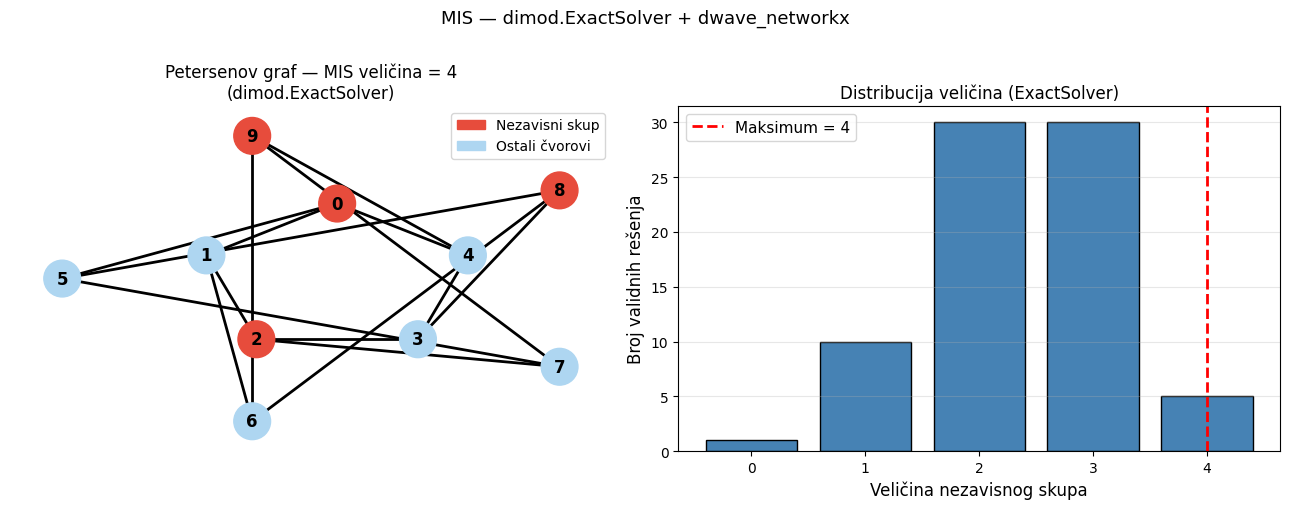

In [18]:
# ── Graf ─────────────────────────────────────────────────
G_mis = nx.petersen_graph()
n_mis = G_mis.number_of_nodes()
P_mis = 3   # kazna > 1 (vrednost jednog čvora)

# ── Pristup A: Ručni dimod BQM + ExactSolver ─────────────
linear_mis    = {i: -1 for i in range(n_mis)}
quadratic_mis = {(i, j): P_mis for i, j in G_mis.edges()}
bqm_mis = dimod.BinaryQuadraticModel(linear_mis, quadratic_mis, 0.0, vartype='BINARY')

exact_mis = exact_solver.sample(bqm_mis)
best_mis  = {v for v, val in exact_mis.first.sample.items() if val == 1}

# ── Pristup B: dwave_networkx.maximum_independent_set ────
mis_dnx = set(dnx.maximum_independent_set(G_mis, sampler=sa_sampler,
                                           lagrange=P_mis, num_reads=500))

def validate_mis(G, mis):
    return all(not (u in mis and v in mis) for u, v in G.edges())

print(f"ExactSolver  → MIS: {sorted(best_mis)}, veličina={len(best_mis)}, validno={'DA ✓' if validate_mis(G_mis, best_mis) else 'NE ✗'}")
print(f"dwave_networkx → MIS: {sorted(mis_dnx)}, veličina={len(mis_dnx)}, validno={'DA ✓' if validate_mis(G_mis, mis_dnx) else 'NE ✗'}")
print(f"\nUkupno rešenja (ExactSolver): {len(exact_mis)}")

# Distribucija veličina validnih nezavisnih skupova
valid_sizes = {}
for sample, energy in exact_mis.data(['sample', 'energy']):
    if all(not (sample[i] and sample[j]) for i, j in G_mis.edges()):
        s = sum(sample.values())
        valid_sizes[s] = valid_sizes.get(s, 0) + 1
max_is_size = max(valid_sizes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pos_mis = nx.shell_layout(G_mis, nlist=[range(5), range(5, 10)])
node_colors_mis = ['#E74C3C' if i in best_mis else '#AED6F1' for i in range(n_mis)]
nx.draw(G_mis, pos_mis, node_color=node_colors_mis, with_labels=True,
        node_size=700, font_size=12, font_weight='bold', width=2, ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color='#E74C3C', label='Nezavisni skup'),
    mpatches.Patch(color='#AED6F1', label='Ostali čvorovi'),
], fontsize=10)
axes[0].set_title(f'Petersenov graf — MIS veličina = {len(best_mis)}\n(dimod.ExactSolver)', fontsize=12)

axes[1].bar(valid_sizes.keys(), valid_sizes.values(), color='steelblue', edgecolor='black')
axes[1].axvline(max_is_size, color='red', linestyle='--', linewidth=2,
                label=f'Maksimum = {max_is_size}')
axes[1].set_xlabel('Veličina nezavisnog skupa', fontsize=12)
axes[1].set_ylabel('Broj validnih rešenja', fontsize=12)
axes[1].set_title('Distribucija veličina (ExactSolver)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('MIS — dimod.ExactSolver + dwave_networkx', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Primer 4: Max-Cut

### Opis problema

Za graf $G = (V, E)$, podeliti čvorove na dva skupa $S$ i $\bar{S}$ tako da se **maksimizuje** broj grana između skupova. Max-Cut se koristi u: dizajnu integrisanih kola (VLSI), statističkoj mehanici (Izing model), klasterizaciji podataka.

### QUBO formulacija

Promenljive: $x_i = 1$ ako $i \in S$, inače $x_i = 0$.

Grana $(i,j)$ je prerezana ako i samo ako $x_i \neq x_j$. Logički izraz za "prerezana":
$$\text{cut}(i,j) = x_i(1-x_j) + x_j(1-x_i) = x_i + x_j - 2x_ix_j$$

Maksimizujemo ukupan broj prerezanih grana:
$$\max \sum_{(i,j)\in E}(x_i + x_j - 2x_ix_j) \quad\Leftrightarrow\quad \min \sum_{(i,j)\in E}(-x_i - x_j + 2x_ix_j)$$

### QUBO matrica (koeficijenti)

Skupljamo linearne i kvadratne doprinose svih grana:
$$Q_{ii} = -\deg(i) \qquad Q_{ij} = 2 \text{ za } (i,j)\in E$$

**Nema ograničenja** — čist QUBO bez kazni i bez slack promenljivih. Svaka asignacija $\mathbf{x}$ je validna particija, razlikuju se samo po kvalitetu reza.

### Zašto je Max-Cut važan za D-Wave?

Max-Cut direktno odgovara Izing modelu — minimizacija Izing hamiltonijana na D-Wave čipu je ekvivalentna Max-Cut rešavanju. Ovo je **nativni problem** za kvantne anil-ere.

### Ocean SDK pristup

Koristimo oba pristupa i upoređujemo:
1. `dwave_networkx.maximum_cut(G, sampler, ...)` — automatski BQM, direktan API
2. Ručni BQM + `ExactSolver` — referentno tačno rešenje
3. `neal.SimulatedAnnealingSampler` — višestruka pokretanja za distribuciju energija

Ukupno grana  : 16
Max-Cut (Exact): 11
SA Max-Cut     : 11
dnx Max-Cut    : 11
S  = [1, 4, 7]
S̄ = [0, 2, 3, 5, 6]


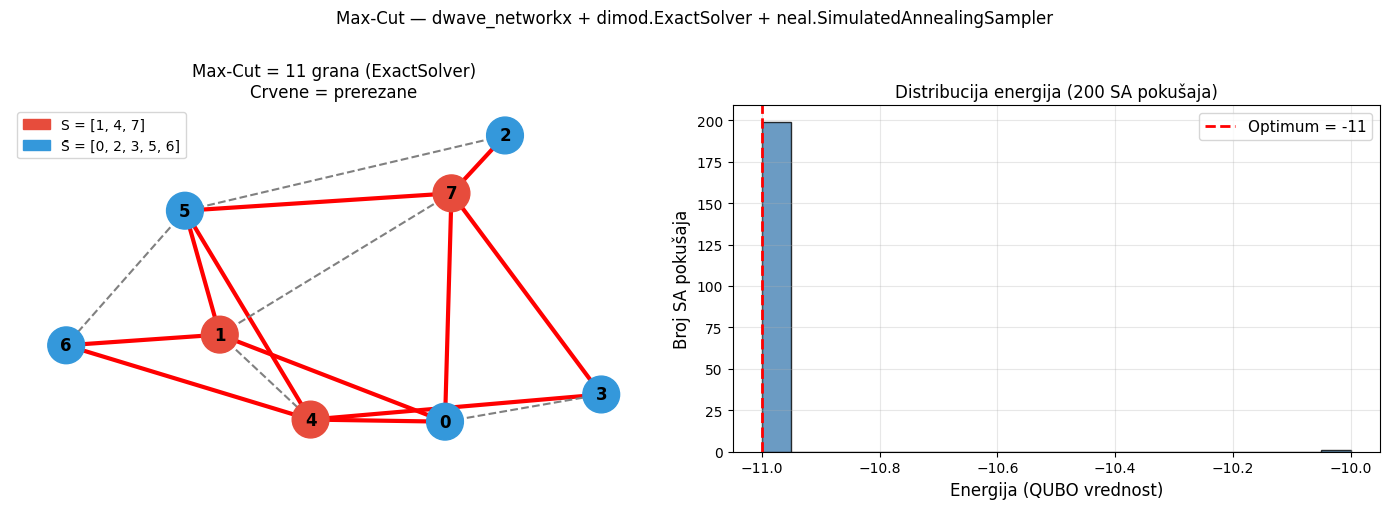

In [17]:
# ── Graf ─────────────────────────────────────────────────
np.random.seed(42)
G_mc = nx.random_geometric_graph(8, 0.55, seed=42)
n_mc = G_mc.number_of_nodes()

# ── Pristup A: dwave_networkx.maximum_cut ────────────────
mc_dnx = set(dnx.maximum_cut(G_mc, sampler=sa_sampler, num_reads=300))

# ── Pristup B: Ručni dimod BQM + ExactSolver ─────────────
linear_mc    = {}
quadratic_mc = {}
for (i, j) in G_mc.edges():
    linear_mc[i] = linear_mc.get(i, 0) - 1
    linear_mc[j] = linear_mc.get(j, 0) - 1
    a, b = (i, j) if i < j else (j, i)
    quadratic_mc[(a, b)] = quadratic_mc.get((a, b), 0) + 2

bqm_mc   = dimod.BinaryQuadraticModel(linear_mc, quadratic_mc, 0.0, vartype='BINARY')
exact_mc  = exact_solver.sample(bqm_mc)
sa_mc     = sa_sampler.sample(bqm_mc, num_reads=200, num_sweeps=3000)

max_cut     = -int(exact_mc.first.energy)
S_exact     = {v for v, val in exact_mc.first.sample.items() if val == 1}
S_bar_exact = set(range(n_mc)) - S_exact
cut_dnx_sz  = sum(1 for i, j in G_mc.edges() if (i in mc_dnx) != (j in mc_dnx))

print(f"Ukupno grana  : {G_mc.number_of_edges()}")
print(f"Max-Cut (Exact): {max_cut}")
print(f"SA Max-Cut     : {-int(sa_mc.first.energy)}")
print(f"dnx Max-Cut    : {cut_dnx_sz}")
print(f"S  = {sorted(S_exact)}")
print(f"S̄ = {sorted(S_bar_exact)}")

cut_edges   = [(i, j) for i, j in G_mc.edges() if (i in S_exact) != (j in S_exact)]
intra_edges = [(i, j) for i, j in G_mc.edges() if (i in S_exact) == (j in S_exact)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_mc = nx.get_node_attributes(G_mc, 'pos')
node_colors_mc = ['#E74C3C' if i in S_exact else '#3498DB' for i in range(n_mc)]
nx.draw_networkx_nodes(G_mc, pos_mc, node_color=node_colors_mc, node_size=700, ax=axes[0])
nx.draw_networkx_labels(G_mc, pos_mc, font_size=12, font_weight='bold', ax=axes[0])
nx.draw_networkx_edges(G_mc, pos_mc, edgelist=cut_edges,
                       edge_color='red', width=3, ax=axes[0])
nx.draw_networkx_edges(G_mc, pos_mc, edgelist=intra_edges,
                       edge_color='gray', width=1.5, style='dashed', ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color='#E74C3C', label=f'S = {sorted(S_exact)}'),
    mpatches.Patch(color='#3498DB', label=f'S̄ = {sorted(S_bar_exact)}'),
], fontsize=10)
axes[0].set_title(f'Max-Cut = {max_cut} grana (ExactSolver)\nCrvene = prerezane', fontsize=12)
axes[0].axis('off')

energies_mc = list(sa_mc.record.energy)
axes[1].hist(energies_mc, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(exact_mc.first.energy, color='red', linestyle='--', linewidth=2,
                label=f'Optimum = {int(exact_mc.first.energy)}')
axes[1].set_xlabel('Energija (QUBO vrednost)', fontsize=12)
axes[1].set_ylabel('Broj SA pokušaja', fontsize=12)
axes[1].set_title('Distribucija energija (200 SA pokušaja)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Max-Cut — dwave_networkx + dimod.ExactSolver + neal.SimulatedAnnealingSampler',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Primer 5: Pokrivanje čvorova (Vertex Cover)

### Opis problema

Pronaći **najmanji skup čvorova** takav da svaka grana grafa ima bar jedan kraj u skupu (skup "pokriva" sve grane).

**Veza sa MIS:** Komplement minimalnog pokrivača je maksimalni nezavisni skup! Ako je $C$ minimalni vertex cover, tada $V \setminus C$ je maksimalni nezavisni skup, i obrnuto.

### QUBO formulacija

Promenljive: $x_i = 1$ ako $i$ pripada pokrivaču.

**Cilj** — minimizovati veličinu pokrivača:
$$\min \sum_i x_i$$

**Ograničenje** — svaka grana $(i,j)$ mora biti pokrivena, tj. $x_i + x_j \geq 1$.

Narušavanje ograničenja za granu $(i,j)$ se dešava jedino kada su oba čvora **van** pokrivača: $x_i = 0$ i $x_j = 0$. Ovo je $(1-x_i)(1-x_j) = 1$.

Kazneni term za svaku granu:
$$P \cdot (1 - x_i)(1 - x_j) = P(1 - x_i - x_j + x_i x_j)$$

**Ukupna QUBO funkcija:**
$$\boxed{f(\mathbf{x}) = \sum_i x_i + P\sum_{(i,j)\in E}(1 - x_i - x_j + x_i x_j)}$$

### Razvijeni QUBO koeficijenti

Skupljamo po terminima za svaki čvor $i$:
- Dijagonala: $Q_{ii} = 1 - P \cdot \deg(i)$
- Van-dijagonale: $Q_{ij} = P$ za $(i,j) \in E$

### Izbor kazne $P$

Treba: $P > 1$ (kazna za nepokrivenu granu mora biti veća od uštede od uklanjanja jednog čvora iz pokrivača).

### Ocean SDK pristup

`dwave_networkx.minimum_vertex_cover` automatski formuliše i rešava problem — koristimo ga uporedo sa ručnim BQM za verifikaciju.

ExactSolver pokrivač   : [0, 3, 5], veličina=3, validno=DA ✓
dwave_networkx pokrivač: [1, 2, 4], veličina=3, validno=DA ✓
QUBO energija          : -32.0


/tmp/ipykernel_13008/1716464284.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


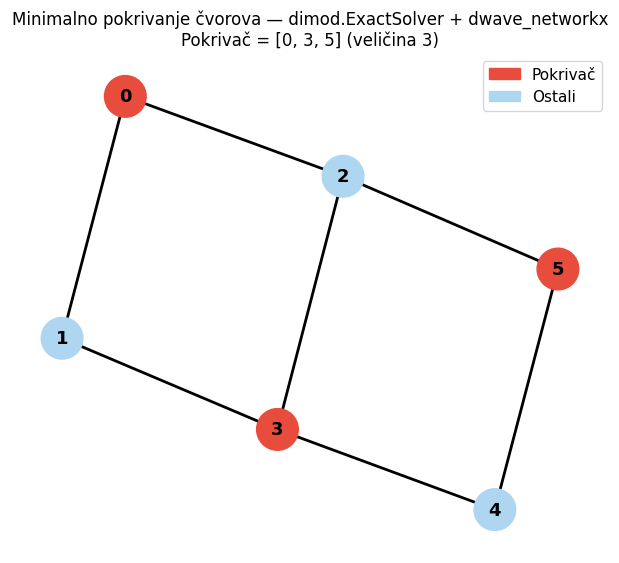

In [16]:
# ── Graf ─────────────────────────────────────────────────
G_vc = nx.Graph()
G_vc.add_edges_from([(0,1),(0,2),(1,3),(2,3),(3,4),(4,5),(2,5)])
n_vc = G_vc.number_of_nodes()
P_vc = 5

# ── Pristup A: dwave_networkx.minimum_vertex_cover ───────
cover_dnx = set(dnx.min_vertex_cover(G_vc, sampler=sa_sampler,
                                          lagrange=P_vc, num_reads=300))

# ── Pristup B: Ručni dimod BQM + ExactSolver ─────────────
linear_vc    = {i: 1 for i in range(n_vc)}
quadratic_vc = {}
for (i, j) in G_vc.edges():
    linear_vc[i] = linear_vc.get(i, 0) - P_vc
    linear_vc[j] = linear_vc.get(j, 0) - P_vc
    a, b = (i, j) if i < j else (j, i)
    quadratic_vc[(a, b)] = quadratic_vc.get((a, b), 0) + P_vc

bqm_vc   = dimod.BinaryQuadraticModel(linear_vc, quadratic_vc, 0.0, vartype='BINARY')
exact_vc  = exact_solver.sample(bqm_vc)
cover     = {i for i, xi in exact_vc.first.sample.items() if xi == 1}

covered_exact = all((i in cover     or j in cover)     for i, j in G_vc.edges())
covered_dnx   = all((i in cover_dnx or j in cover_dnx) for i, j in G_vc.edges())

print(f"ExactSolver pokrivač   : {sorted(cover)}, veličina={len(cover)}, validno={'DA ✓' if covered_exact else 'NE ✗'}")
print(f"dwave_networkx pokrivač: {sorted(cover_dnx)}, veličina={len(cover_dnx)}, validno={'DA ✓' if covered_dnx else 'NE ✗'}")
print(f"QUBO energija          : {exact_vc.first.energy:.1f}")

# Vizualizacija
pos_vc = nx.spring_layout(G_vc, seed=7)
node_colors_vc = ['#E74C3C' if i in cover else '#AED6F1' for i in range(n_vc)]
plt.figure(figsize=(6, 5))
nx.draw(G_vc, pos_vc, node_color=node_colors_vc, with_labels=True,
        node_size=900, font_size=13, font_weight='bold', width=2)
plt.legend(handles=[
    mpatches.Patch(color='#E74C3C', label='Pokrivač'),
    mpatches.Patch(color='#AED6F1', label='Ostali'),
], fontsize=11)
plt.title(f'Minimalno pokrivanje čvorova — dimod.ExactSolver + dwave_networkx\n'
          f'Pokrivač = {sorted(cover)} (veličina {len(cover)})', fontsize=12)
plt.tight_layout()
plt.show()

## Primer 6: Binarno linearno programiranje (Binary LP)

### Opis problema

Minimizovati linearnu funkciju uz linearna jednakosna ograničenja:

$$\min_{\mathbf{x}} \mathbf{c}^T \mathbf{x}$$
$$\text{uz uslov: } A\mathbf{x} = \mathbf{b}, \quad x_i \in \{0,1\}$$

Ovo je **opšti okvir** koji obuhvata mnoge kombinatorne optimizacione probleme — Knapsack, bojenje grafova, TSP, planiranje zadataka — svi se mogu svesti na ovaj oblik.

### QUBO formulacija

Svako jednakosno ograničenje $\mathbf{a}_k^T \mathbf{x} = b_k$ enkodujemo kaznenim kvadratom:
$$P_k \cdot (\mathbf{a}_k^T \mathbf{x} - b_k)^2$$

Razvijanjem dobijamo:
$$P_k \left(\sum_i a_{ki}^2 x_i + 2\sum_{i<j} a_{ki} a_{kj} x_i x_j - 2b_k \sum_i a_{ki} x_i\right)$$

**Ukupna QUBO funkcija:**
$$f(\mathbf{x}) = \mathbf{c}^T \mathbf{x} + \sum_k P_k \cdot (\mathbf{a}_k^T \mathbf{x} - b_k)^2$$

### Konkretna instanca (biramo tačno 2 od 4)

$$\min\; -3x_1 - 5x_2 - 2x_3 - 4x_4 \qquad \text{uz} \quad x_1 + x_2 + x_3 + x_4 = 2$$

Ovo je zapravo "Izaberi 2 najtjvrednija predmeta" — optimum je $x_2 = x_4 = 1$ (vrednosti 5 i 4).

### Izbor kazne $P$

Kazna mora nadmašiti razliku između najboljeg i najgoreg validnog rešenja:
$$P > \max_{\text{validna}} f_{\text{obj}} - \min_{\text{validna}} f_{\text{obj}}$$

Za naš primer: validna rešenja imaju ciljne vrednosti u opsegu $[-9, -5]$ → razlika 4 → $P > 4$.

### Napomena o `ConstrainedQuadraticModel` (CQM)

Ocean SDK nudi i moderniji API — `dimod.ConstrainedQuadraticModel` koji prima cilj i ograničenja odvojeno, bez ručnog računanja kazni. CQM zahteva D-Wave Leap hibridni solver, dok BQM radi sa svim samplerima.

In [15]:
# ── Problem: min c^T x  uz  sum(x) = 2 ──────────────────
c_lp = np.array([-3, -5, -2, -4], dtype=float)
a_lp = np.ones(4)
b_lp = 2
P_lp = 20
n_lp = len(c_lp)

# ── Gradnja dimod BQM ────────────────────────────────────
linear_lp    = {}
quadratic_lp = {}
for i in range(n_lp):
    linear_lp[i] = c_lp[i] + P_lp * (a_lp[i]**2 - 2*b_lp*a_lp[i])
for i in range(n_lp):
    for j in range(i+1, n_lp):
        quadratic_lp[(i, j)] = P_lp * 2 * a_lp[i] * a_lp[j]

bqm_lp   = dimod.BinaryQuadraticModel(linear_lp, quadratic_lp, 0.0, vartype='BINARY')
exact_lp  = exact_solver.sample(bqm_lp)

print(f"{'x':>12} | {'Cilj c^Tx':>10} | {'Uslov (Σxi=2)':>14} | {'QUBO f':>8}")
print("-" * 55)
for sample, energy in exact_lp.data(['sample', 'energy']):
    x_vec = tuple(sample[i] for i in range(n_lp))
    obj   = float(np.dot(c_lp, x_vec))
    feas  = abs(np.dot(a_lp, x_vec) - b_lp) < 1e-9
    marker = " ←★" if energy == exact_lp.first.energy else ""
    print(f"{str(x_vec):>12} | {obj:>10.1f} | {'DA' if feas else 'NE':>14} | {energy:>8.1f}{marker}")

best_lp = exact_lp.first
x_opt   = tuple(best_lp.sample[i] for i in range(n_lp))
obj_opt = float(np.dot(c_lp, x_opt))

print(f"\nOptimalno rešenje : x* = {x_opt}")
print(f"Vrednost cilja    : c^T x* = {obj_opt:.1f}")
print(f"Ograničenje       : Σx* = {sum(x_opt)} (treba = {int(b_lp)})")
print(f"QUBO energija     : {best_lp.energy:.1f}")

           x |  Cilj c^Tx |  Uslov (Σxi=2) |   QUBO f
-------------------------------------------------------
(np.int8(0), np.int8(1), np.int8(0), np.int8(1)) |       -9.0 |             DA |    -89.0 ←★
(np.int8(1), np.int8(1), np.int8(0), np.int8(0)) |       -8.0 |             DA |    -88.0
(np.int8(1), np.int8(0), np.int8(0), np.int8(1)) |       -7.0 |             DA |    -87.0
(np.int8(0), np.int8(1), np.int8(1), np.int8(0)) |       -7.0 |             DA |    -87.0
(np.int8(0), np.int8(0), np.int8(1), np.int8(1)) |       -6.0 |             DA |    -86.0
(np.int8(1), np.int8(0), np.int8(1), np.int8(0)) |       -5.0 |             DA |    -85.0
(np.int8(1), np.int8(1), np.int8(0), np.int8(1)) |      -12.0 |             NE |    -72.0
(np.int8(0), np.int8(1), np.int8(1), np.int8(1)) |      -11.0 |             NE |    -71.0
(np.int8(1), np.int8(1), np.int8(1), np.int8(0)) |      -10.0 |             NE |    -70.0
(np.int8(1), np.int8(0), np.int8(1), np.int8(1)) |       -9.0 |             N

## Rezime — QUBO formulacije i Ocean SDK alati

### Jednostavni uvodni primeri

| Primer | Problem | QUBO struktura | Sampler |
|---|---|---|---|
| **0 — Hello QUBO** | Minimizuj $x_1+x_2-2x_1x_2$ | 2 promenljive, direktno | `ExactSolver` |
| **1 — One-Hot** | Izaberi tačno 1 od $n$ | $P(1-\sum x_i)^2$ | `ExactSolver` |
| **2 — 2-Way particija** | Podeli u 2 grupe jednakih suma | $(2\sum a_ix_i - S)^2$ | `ExactSolver` |

### Kompleksni primeri

| Primer | Problem | Promenljive | D-Wave alat |
|---|---|---|---|
| **1 — Knapsack** | Maks. vrednost uz kapacitet | $n$ + slack bita | `dimod.BQM` + `neal.SA` |
| **2 — Bojenje grafa** | Boji čvorove bez konflikata | $n \times k$ (one-hot) | `dimod.BQM` + `ExactSolver` |
| **3 — MIS** | Najveći nezavisni skup | $n$ | `dwave_networkx.maximum_independent_set` |
| **4 — Max-Cut** | Maks. broj prerezanih grana | $n$ | `dwave_networkx.maximum_cut` |
| **5 — Vertex Cover** | Minimalno pokrivanje grana | $n$ | `dwave_networkx.minimum_vertex_cover` |
| **6 — Binary LP** | Min $\mathbf{c}^T\mathbf{x}$ uz $A\mathbf{x}=\mathbf{b}$ | $n$ | `dimod.BQM` + `ExactSolver` |
| **7 — K-Way particija** | Podeli u $K$ jednakih grupa | $n \times K$ (one-hot) | `dimod.BQM` + `ExactSolver` + `neal.SA` |

### Ocean SDK sampleri korišćeni u ovom notebooku

| Sampler | Paket | Kada koristiti |
|---|---|---|
| `ExactSolver` | `dimod` | $n \leq 20$ — garantuje globalni optimum |
| `SimulatedAnnealingSampler` | `neal` | $n > 20$ — heuristika, višestruka pokretanja |
| `maximum_independent_set` | `dwave_networkx` | MIS — automatski BQM i rešavanje |
| `maximum_cut` | `dwave_networkx` | Max-Cut — automatski BQM i rešavanje |
| `minimum_vertex_cover` | `dwave_networkx` | Vertex Cover — automatski BQM i rešavanje |

### Gradivni blokovi QUBO formulacija

| Blok | Formula | Gde se koristi |
|---|---|---|
| **One-hot** | $P(1-\sum_i x_i)^2$ | Bojenje grafa, K-way particija, TSP |
| **Jednakosno ograničenje** | $P(\sum_i a_i x_i - b)^2$ | Knapsack (slack), Binary LP, particija |
| **Kazna za granu** | $P \cdot x_i x_j$ za $(i,j)\in E$ | MIS, bojenje grafa |
| **Negativan cilj** | $-\sum_i v_i x_i$ | Knapsack, MIS |
| **Čist rez** | $\sum_{(i,j)}(-x_i - x_j + 2x_ix_j)$ | Max-Cut (bez ograničenja) |

### Izbor kazne $P$

$$P > \max_{\text{validna } \mathbf{x}} f_{\text{obj}}(\mathbf{x}) - \min_{\text{validna } \mathbf{x}} f_{\text{obj}}(\mathbf{x})$$

Prekrupna $P$ čini QUBO numerički nestabilnim. Optimalan izbor je najtanja moguća kazna koja garantuje validnost rešenja.

Brojevi  : [1, 2, 3, 4, 5]
Suma     : S = 15
K grupi  : K = 3
Cilj/grupi: T = S/K = 5

BQM: 15 promenljivih (5 × 3), 45 interakcija

OPTIMALNO REŠENJE (ExactSolver):
  Grupa 1: [5]  →  suma = 5
  Grupa 2: [1, 4]  →  suma = 5
  Grupa 3: [2, 3]  →  suma = 5
Validno: DA ✓
Energija (Exact): -1200.0  (0 = savršena particija)

SA pronašla optimum: DA ✓
SA energija       : -1200.0


/tmp/ipykernel_13008/3221362693.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


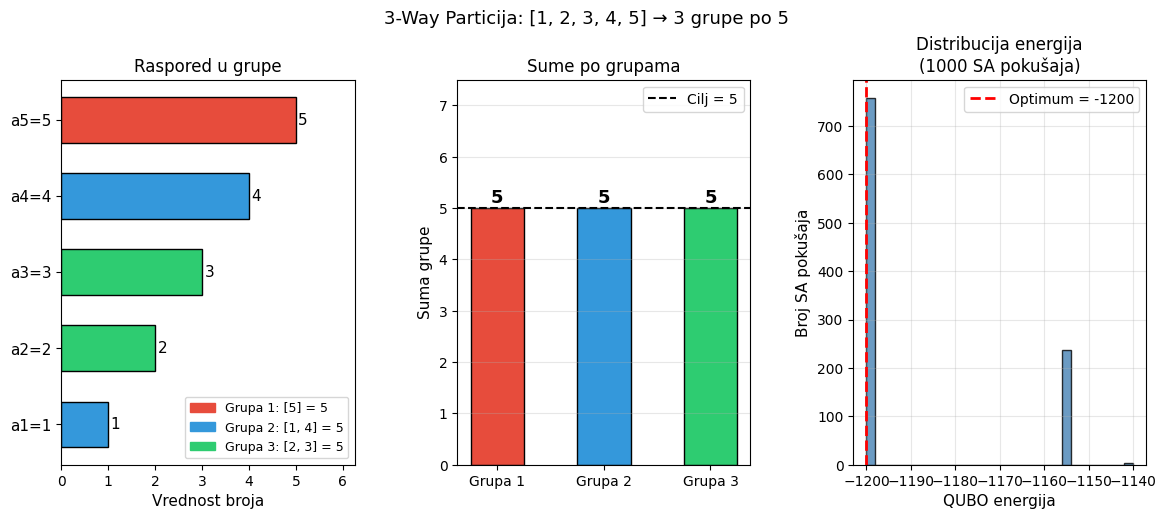

In [14]:
import matplotlib.gridspec as gridspec

# ── Podaci ───────────────────────────────────────────────
# {1,2,3,4,5} → suma=15, svaka od 3 grupe treba da ima sumu 5
# Rešenje: {1,4}, {2,3}, {5}
nums = [1, 2, 3, 4, 5]
K    = 3                          # broj grupa
n    = len(nums)
S3   = sum(nums)
T    = S3 // K                    # ciljna suma po grupi

print(f"Brojevi  : {nums}")
print(f"Suma     : S = {S3}")
print(f"K grupi  : K = {K}")
print(f"Cilj/grupi: T = S/K = {T}")
print()
assert S3 % K == 0, f"Suma {S3} nije deljiva sa {K} — savršena particija ne postoji!"

P1 = 15    # kazna za one-hot (svaki broj mora biti u tačno jednoj grupi)
P2 = 15    # kazna za nejednake sume

# ── Enkodovanje ───────────────────────────────────────────
# x[i, g] = 1 ako broj nums[i] ide u grupu g
# Indeks u BQM-u: varijable su torke (i, g)
def var(i, g): return (i, g)

linear_3p    = {}
quadratic_3p = {}

# ── Ograničenje 1: svaki broj ide u tačno jednu grupu (one-hot po broju) ──
for i in range(n):
    for g in range(K):
        linear_3p[var(i, g)] = linear_3p.get(var(i, g), 0) - P1          # -P1 * x[i,g]
    for g1 in range(K):
        for g2 in range(g1+1, K):
            key = (var(i, g1), var(i, g2))
            quadratic_3p[key] = quadratic_3p.get(key, 0) + 2 * P1        # +2P1 * x[i,g1]*x[i,g2]

# ── Ograničenje 2: suma svake grupe = T ──────────────────
# P2 * (Σ_i nums[i]*x[i,g] - T)^2  za svaku grupu g
for g in range(K):
    a_g = [nums[i] for i in range(n)]
    for i in range(n):
        linear_3p[var(i, g)] = linear_3p.get(var(i, g), 0) + P2 * (a_g[i]**2 - 2*T*a_g[i])
    for i in range(n):
        for j in range(i+1, n):
            key = (var(i, g), var(j, g))
            quadratic_3p[key] = quadratic_3p.get(key, 0) + P2 * 2 * a_g[i] * a_g[j]

bqm_3p = dimod.BinaryQuadraticModel(linear_3p, quadratic_3p, 0.0, vartype='BINARY')
print(f"BQM: {len(bqm_3p.variables)} promenljivih ({n} × {K}), {len(bqm_3p.quadratic)} interakcija")

# ── Rešavanje: ExactSolver (2^15 = 32768, izvodljivo) ────
exact_3p = exact_solver.sample(bqm_3p)
sa_3p    = sa_sampler.sample(bqm_3p, num_reads=1000, num_sweeps=5000)

# ── Dekodiranje i validacija ──────────────────────────────
def decode_3p(sample):
    groups = [[] for _ in range(K)]
    valid  = True
    for i in range(n):
        assigned = [g for g in range(K) if sample[var(i, g)] == 1]
        if len(assigned) != 1:
            valid = False
            groups[0].append(nums[i])      # fallback
        else:
            groups[assigned[0]].append(nums[i])
    sums_ok = all(sum(groups[g]) == T for g in range(K))
    return groups, valid and sums_ok

groups_exact, valid_exact = decode_3p(exact_3p.first.sample)
groups_sa,    valid_sa    = decode_3p(sa_3p.first.sample)

print("\n" + "="*50)
print("OPTIMALNO REŠENJE (ExactSolver):")
print("="*50)
for g, grp in enumerate(groups_exact):
    print(f"  Grupa {g+1}: {grp}  →  suma = {sum(grp)}")
print(f"Validno: {'DA ✓' if valid_exact else 'NE ✗'}")
print(f"Energija (Exact): {exact_3p.first.energy:.1f}  (0 = savršena particija)")

print(f"\nSA pronašla optimum: {'DA ✓' if sa_3p.first.energy == exact_3p.first.energy else 'NE ✗'}")
print(f"SA energija       : {sa_3p.first.energy:.1f}")

# ── Vizualizacija ─────────────────────────────────────────
group_colors = ['#E74C3C', '#3498DB', '#2ECC71']
group_labels = ['Grupa 1', 'Grupa 2', 'Grupa 3']

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Levo: prikaz particije kao horizontalne trake
ax0 = fig.add_subplot(gs[0])
y_positions = list(range(n))
bar_colors  = []
bar_labels  = []
for i in range(n):
    assigned = [g for g in range(K) if exact_3p.first.sample[var(i, g)] == 1]
    g = assigned[0] if assigned else 0
    bar_colors.append(group_colors[g])
    bar_labels.append(group_labels[g])

bars = ax0.barh(y_positions, nums, color=bar_colors, edgecolor='black', height=0.6)
for bar, num in zip(bars, nums):
    ax0.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(num), va='center', fontsize=11)
ax0.set_yticks(y_positions)
ax0.set_yticklabels([f'a{i+1}={nums[i]}' for i in range(n)], fontsize=11)
ax0.set_xlabel('Vrednost broja', fontsize=11)
ax0.set_title('Raspored u grupe', fontsize=12)
ax0.set_xlim(0, max(nums) * 1.25)
handles = [mpatches.Patch(color=group_colors[g],
           label=f'{group_labels[g]}: {groups_exact[g]} = {sum(groups_exact[g])}')
           for g in range(K)]
ax0.legend(handles=handles, fontsize=9, loc='lower right')

# Sredina: suma po grupama
ax1 = fig.add_subplot(gs[1])
sums = [sum(groups_exact[g]) for g in range(K)]
bars2 = ax1.bar(group_labels, sums, color=group_colors, edgecolor='black', width=0.5)
ax1.axhline(T, color='black', linestyle='--', linewidth=1.5, label=f'Cilj = {T}')
for bar, s in zip(bars2, sums):
    ax1.text(bar.get_x() + bar.get_width()/2, s + 0.1, str(s),
             ha='center', fontsize=13, fontweight='bold')
ax1.set_ylabel('Suma grupe', fontsize=11)
ax1.set_title('Sume po grupama', fontsize=12)
ax1.set_ylim(0, T * 1.5)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

# Desno: distribucija energija (SA)
ax2 = fig.add_subplot(gs[2])
sa_energies_3p = list(sa_3p.record.energy)
ax2.hist(sa_energies_3p, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax2.axvline(exact_3p.first.energy, color='red', linestyle='--', linewidth=2,
            label=f'Optimum = {exact_3p.first.energy:.0f}')
ax2.set_xlabel('QUBO energija', fontsize=11)
ax2.set_ylabel('Broj SA pokušaja', fontsize=11)
ax2.set_title('Distribucija energija\n(1000 SA pokušaja)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle(f'3-Way Particija: {nums} → 3 grupe po {T}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Rezime — QUBO formulacije i Ocean SDK alati

### Jednostavni uvodni primeri

| Primer | Promenljive | QUBO struktura | Sampler |
|---|---|---|---|
| **Hello QUBO** | $x_1, x_2$ | $x_1 + x_2 - 2x_1x_2$ | `ExactSolver` |
| **One-Hot odabir** | $x_1,\dots,x_n$ | $P(1-\sum x_i)^2$ | `ExactSolver` |
| **Particija skupa** | $x_i$ = grupi 1? | $(2\sum a_i x_i - S)^2$ | `ExactSolver` |

### Kompleksni primeri

| Problem | QUBO cilj | Ograničenja | D-Wave alat |
|---|---|---|---|
| **Knapsack** | $-\sum v_i x_i$ | Slack bita za kapacitet | `dimod.BQM` + `neal.SA` |
| **Bojenje grafa** | $0$ | Kazna za konflikte + one-hot | `dimod.BQM` + `ExactSolver` |
| **Maks. nezavisni skup** | $-\sum x_i$ | $P\sum_{(i,j)} x_ix_j$ | `dwave_networkx.maximum_independent_set` |
| **Max-Cut** | $\sum(-x_i-x_j+2x_ix_j)$ | — | `dwave_networkx.maximum_cut` |
| **Pokrivanje čvorova** | $\sum x_i$ | $P(1-x_i)(1-x_j)$ | `dwave_networkx.minimum_vertex_cover` |
| **Binarno lin. prog.** | $\mathbf{c}^T\mathbf{x}$ | $P(\mathbf{a}^T\mathbf{x}-b)^2$ | `dimod.BQM` + `ExactSolver` |

### Ocean SDK sampleri korišćeni u ovom notebooku

| Sampler | Paket | Kada koristiti |
|---|---|---|
| `ExactSolver` | `dimod` | Manji problemi ($n \leq 20$) — garantuje optimum |
| `SimulatedAnnealingSampler` | `neal` | Veći problemi — heuristika, ne garantuje optimum |
| `maximum_independent_set` | `dwave_networkx` | Graf MIS — automatska QUBO gradnja |
| `maximum_cut` | `dwave_networkx` | Graf Max-Cut — automatska QUBO gradnja |
| `minimum_vertex_cover` | `dwave_networkx` | Graf Vertex Cover — automatska QUBO gradnja |

### Izbor kazne $P$

$$P > \max_{\text{validna } \mathbf{x}} f_{\text{obj}}(\mathbf{x}) - \min_{\text{validna } \mathbf{x}} f_{\text{obj}}(\mathbf{x})$$

Prekrupna $P$ čini QUBO numerički nestabilnim — sve kazne dominiraju ciljem. Optimalan izbor je najtanja moguća kazna koja još uvek garantuje validnost.

### Tok rada sa Ocean SDK

```
Problem → dimod.BinaryQuadraticModel → Sampler → SampleSet → .first.sample
                                           ↑
                              ExactSolver / SimulatedAnnealingSampler
                              / dwave_networkx / DWaveSampler (hardver)
```